# IRI RP modeling

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar
import ocha_stratus as stratus
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.special import expit  # logistic function


from src.constants import *

In [3]:
blob_name = f"{PROJECT_PREFIX}/processed/iri_cerf_stats.parquet"
df_stats_iri = stratus.load_parquet_from_blob(blob_name)

In [11]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/chirps/chirps_dek_season_cumul.parquet"
)
df_chirps_raw = stratus.load_parquet_from_blob(blob_name)

In [12]:
df_chirps_final = df_chirps_raw[df_chirps_raw["dekad_overall"] == 27]

In [13]:
df_stats_iri = df_stats_iri.merge(
    df_chirps_final[["year", "rfh_all_cumul", "rfh_aoi_cumul"]]
)

In [14]:
n_total_years = df_stats_iri["year"].nunique()
rp_overall_target = 7
n_years_overall_target = int((n_total_years + 1) / rp_overall_target)

In [15]:
n_years_overall_target

5

In [19]:
col = "rfh_all_cumul"

df_stats_iri["obsv_target"] = (
    df_stats_iri[col]
    <= df_stats_iri[col].nsmallest(n_years_overall_target).max()
)

In [20]:
df_model = df_stats_iri[df_stats_iri["year"] >= 1991].copy()
df_model["obsv_target"] = df_model["obsv_target"].astype(int)

# Center year for stability
df_model["year_c"] = df_model["year"] - df_model["year"].mean()

# Design matrix
X = sm.add_constant(df_model["year_c"])
y = df_model["obsv_target"]

# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.353138
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            obsv_target   No. Observations:                   35
Model:                          Logit   Df Residuals:                       33
Method:                           MLE   Df Model:                            1
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                  0.1389
Time:                        12:15:07   Log-Likelihood:                -12.360
converged:                       True   LL-Null:                       -14.354
Covariance Type:            nonrobust   LLR p-value:                   0.04581
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1948      0.668     -3.283      0.001      -3.505      -0.885
year_c        -0.1096      0.

In [21]:
odds_ratio = np.exp(result.params["year_c"])
print("Odds ratio per year:", odds_ratio)

Odds ratio per year: 0.896179522893064


In [22]:
next_year = df_model["year"].max() + 1
next_year_c = next_year - df_model["year"].mean()

X_next = sm.add_constant(np.array([[next_year_c]]), has_constant="add")

p_next = result.predict(X_next)[0]

print(f"Predicted probability for {next_year}: {p_next:.3f}")

Predicted probability for 2026: 0.015


Text(0, 0.5, 'Estimated return period')

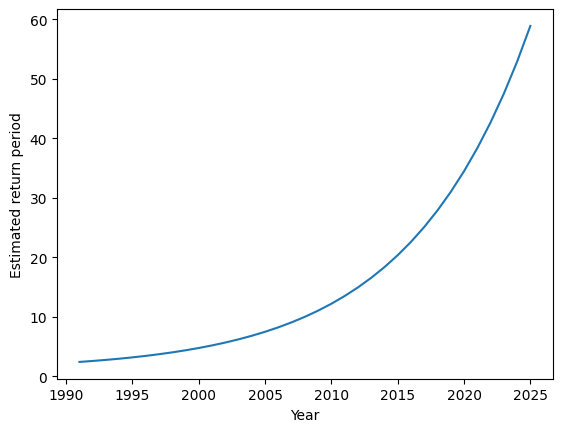

In [23]:
df_model["p_hat"] = result.predict(X)
df_model["rp_hat"] = 1 / df_model["p_hat"]

fig, ax = plt.subplots()

# ax.scatter(df_model["year"], df_model["obsv_target"], alpha=0.6)
ax.plot(df_model["year"], df_model["rp_hat"])

# ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Year")
ax.set_ylabel("Estimated return period")

In [24]:
df_model.groupby(df_model["year"] > df_model["year"].median())[
    "obsv_target"
].mean()

year
False    0.222222
True     0.058824
Name: obsv_target, dtype: float64

In [25]:
df_model.columns

Index(['year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
       'Humanitarian Bad Years (rank)', 'EM-DAT Bad Years',
       'CHIRPS Precip JAS (mm)', 'emdat_float', 'Amount in US$',
       'rfh_all_cumul', 'rfh_aoi_cumul', 'obsv_target', 'year_c', 'p_hat',
       'rp_hat'],
      dtype='object')

In [26]:
rp_model = 5

nyears_trig_model = int((len(df_model) + 1) / rp_model)

In [27]:
nyears_trig_model

7

In [28]:
for col in ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "rfh_all_cumul_rank"]:
    print(col)
    # Design matrix
    X = sm.add_constant(df_model["year_c"])
    y = df_model[col]

    # Fit logistic regression
    model = sm.OLS(y, X)
    result = model.fit()

    print(result.summary())

Jan
                            OLS Regression Results                            
Dep. Variable:                    Jan   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     32.03
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           2.63e-06
Time:                        12:15:13   Log-Likelihood:                -91.019
No. Observations:                  35   AIC:                             186.0
Df Residuals:                      33   BIC:                             189.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.3571      0.567     53.500     

KeyError: 'rfh_all_cumul_rank'

In [29]:
col = "Jun"

thresh = df_model[col].nlargest(nyears_trig_model).min()
df_model[f"{col}_trig"] = (df_model[col] >= thresh).astype(int)

In [30]:
thresh

np.float64(35.1)

                            OLS Regression Results                            
Dep. Variable:                    Jun   R-squared:                       0.503
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     33.44
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.83e-06
Time:                        12:15:14   Log-Likelihood:                -103.06
No. Observations:                  35   AIC:                             210.1
Df Residuals:                      33   BIC:                             213.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.8000      0.800     37.229      0.0

Text(0, 0.5, 'Jun')

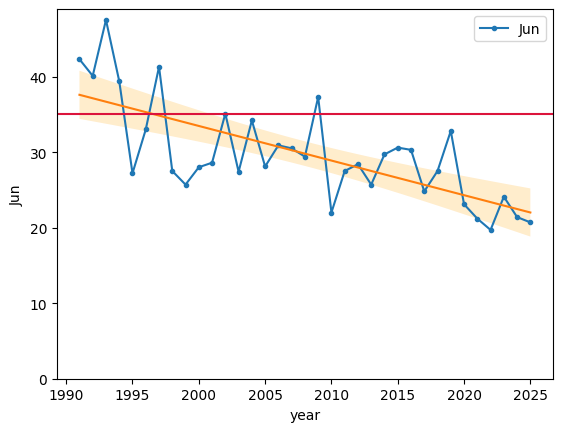

In [31]:
X = sm.add_constant(df_model["year_c"])
y = df_model[col]

# Fit logistic regression
model = sm.OLS(y, X)
result = model.fit()

print(result.summary())

# Prediction on observed data
pred = result.get_prediction(X)
pred_summary = pred.summary_frame(alpha=0.05)

df_model["y_hat"] = pred_summary["mean"]
df_model["ci_lower"] = pred_summary["mean_ci_lower"]
df_model["ci_upper"] = pred_summary["mean_ci_upper"]


fig, ax = plt.subplots()

# Raw data
df_model.plot(x="year", y=col, ax=ax, marker=".")

# Fitted line
ax.plot(df_model["year"], df_model["y_hat"])

ax.axhline(thresh, color="crimson")

# Confidence band
ax.fill_between(
    df_model["year"],
    df_model["ci_lower"],
    df_model["ci_upper"],
    alpha=0.2,
    facecolor="orange",
)

ax.set_ylim(bottom=0)
ax.set_ylabel(col)

Optimization terminated successfully.
         Current function value: 0.309190
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               Jun_trig   No. Observations:                   35
Model:                          Logit   Df Residuals:                       33
Method:                           MLE   Df Model:                            1
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                  0.3821
Time:                        12:15:16   Log-Likelihood:                -10.822
converged:                       True   LL-Null:                       -17.514
Covariance Type:            nonrobust   LLR p-value:                 0.0002537
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6509      0.978     -2.711      0.007      -4.567      -0.734
year_c        -0.2317      0.

Text(0, 0.5, 'Estimated return period')

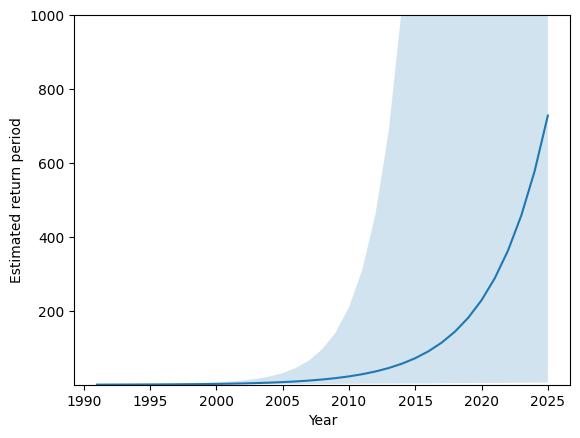

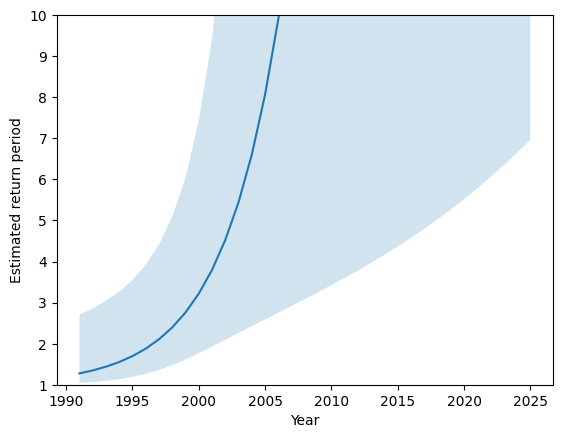

In [32]:
col = "Jun"
df_model[f"{col}_trig"] = (
    df_model[col] >= df_model[col].nlargest(nyears_trig_model).min()
)

# Design matrix
X = sm.add_constant(df_model["year_c"])
y = df_model[f"{col}_trig"]

# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

print(np.exp(result.params["year_c"]))

# Get prediction (already on probability scale for Logit)
pred = result.get_prediction(X)
pred_summary = pred.summary_frame(alpha=0.05)

# Inspect columns if unsure:
# print(pred_summary.columns)

# These are probabilities directly
p_mean = pred_summary["predicted"]
p_lower = pred_summary["ci_lower"]
p_upper = pred_summary["ci_upper"]

# Convert to return period
df_model["rp_hat"] = 1 / p_mean

# Inversion flips bounds
df_model["rp_lower"] = 1 / p_upper
df_model["rp_upper"] = 1 / p_lower

df_model["p_hat"] = result.predict(X)
df_model["rp_hat"] = 1 / df_model["p_hat"]

fig, ax = plt.subplots()

ax.plot(df_model["year"], df_model["rp_hat"])

ax.fill_between(
    df_model["year"], df_model["rp_lower"], df_model["rp_upper"], alpha=0.2
)

ax.set_ylim((1, 1000))

ax.set_xlabel("Year")
ax.set_ylabel("Estimated return period")

fig, ax = plt.subplots()

ax.plot(df_model["year"], df_model["rp_hat"])

ax.fill_between(
    df_model["year"], df_model["rp_lower"], df_model["rp_upper"], alpha=0.2
)

ax.set_ylim((1, 10))

ax.set_xlabel("Year")
ax.set_ylabel("Estimated return period")


P-values for year_c:

Feb: p = 0.0824, coef = -0.0864, odds ratio = 0.917
Mar: p = 0.4524, coef = -0.0307, odds ratio = 0.970
Apr: p = 0.1573, coef = -0.0657, odds ratio = 0.936
May: p = 0.0371, coef = -0.1169, odds ratio = 0.890
Jun: p = 0.0124, coef = -0.2317, odds ratio = 0.793


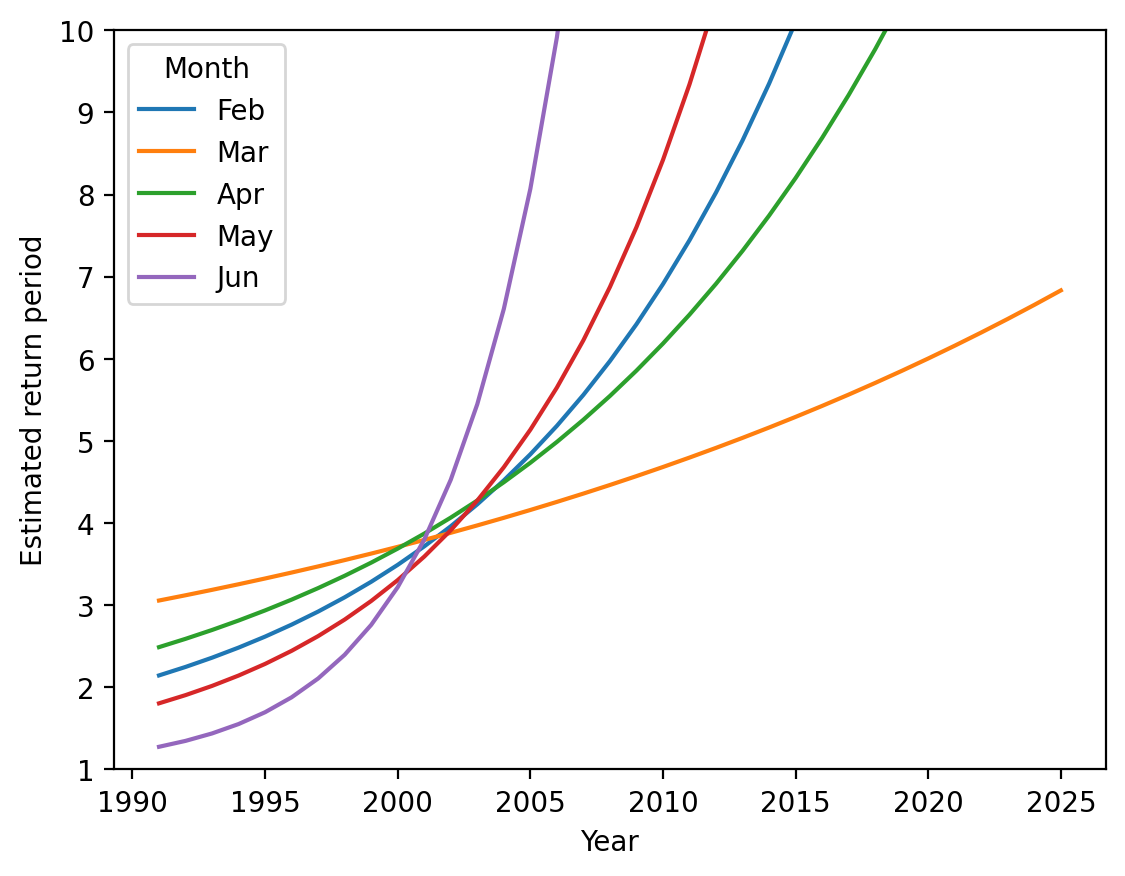

In [41]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

months = ["Feb", "Mar", "Apr", "May", "Jun"]

rp_results = {}

print("\nP-values for year_c:\n")

for col in months:

    # Trigger definition
    df_model[f"{col}_trig"] = (
        df_model[col] >= df_model[col].nlargest(nyears_trig_model).min()
    )

    # Design matrix
    X = sm.add_constant(df_model["year_c"])
    y = df_model[f"{col}_trig"]

    # Fit logistic regression
    model = sm.Logit(y, X)
    result = model.fit(disp=False)

    # Print p-value for trend
    pval = result.pvalues["year_c"]
    coef = result.params["year_c"]
    odds_ratio = np.exp(coef)

    print(
        f"{col}: "
        f"p = {pval:.4f}, "
        f"coef = {coef:.4f}, "
        f"odds ratio = {odds_ratio:.3f}"
    )

    # Get prediction + CI
    pred = result.get_prediction(X)
    pred_summary = pred.summary_frame(alpha=0.05)

    p_mean = pred_summary["predicted"]
    p_lower = pred_summary["ci_lower"]
    p_upper = pred_summary["ci_upper"]

    # Convert to return period
    rp_hat = 1 / p_mean
    rp_lower = 1 / p_upper
    rp_upper = 1 / p_lower

    rp_results[col] = {
        "rp_hat": rp_hat,
        "rp_lower": rp_lower,
        "rp_upper": rp_upper,
    }


# -----------------------
# Plot
# -----------------------

fig, ax = plt.subplots(dpi=200)

for col in months:

    ax.plot(
        df_model["year"],
        rp_results[col]["rp_hat"],
        label=col,
    )

    # ax.fill_between(
    #     df_model["year"],
    #     rp_results[col]["rp_lower"],
    #     rp_results[col]["rp_upper"],
    #     alpha=0.1,
    # )

ax.set_ylim((1, 10))
ax.set_xlabel("Year")
ax.set_ylabel("Estimated return period")
ax.legend(title="Month")

plt.show()

/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_81451/458198860.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  rp_eff = (current_year - 1991 + 1) / total_trigs


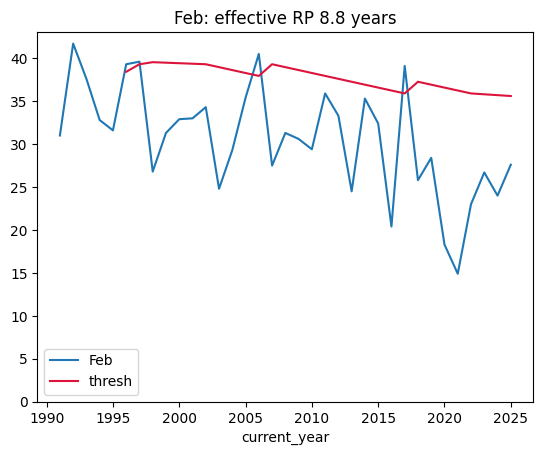

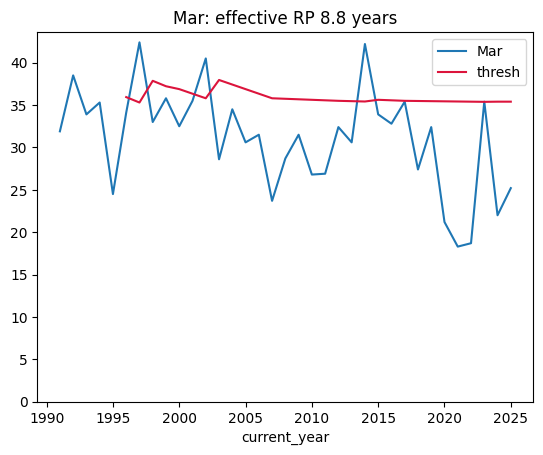

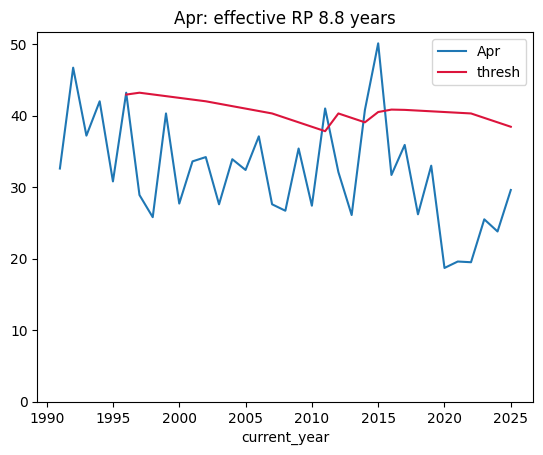

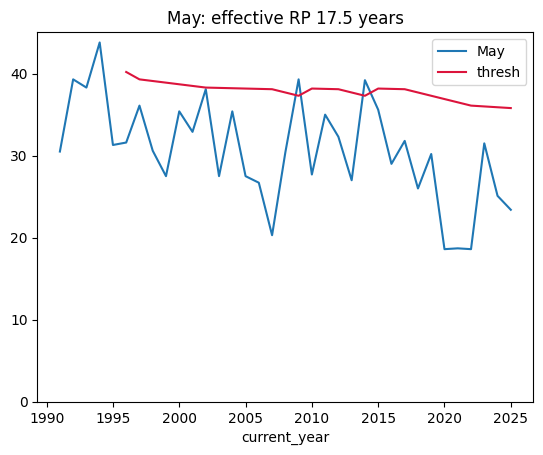

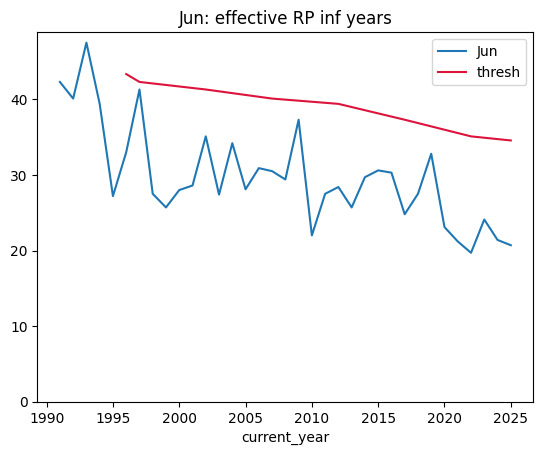

In [35]:
quantile = 0.2

for mo in range(2, 7):
    col = calendar.month_abbr[mo]

    dicts = []
    for current_year in range(1991 + 5, 2026):
        df_past = df_model[df_model["year"] < current_year]
        current_row = df_model.set_index("year").loc[current_year]
        thresh = df_past[col].quantile(1 - quantile)
        trig = current_row[col] >= thresh

        dicts.append(
            {
                "current_year": current_year,
                "thresh": thresh,
                "trig": trig,
            }
        )

    df_wf_trigs = pd.DataFrame(dicts)

    total_trigs = df_wf_trigs["trig"].sum()
    rp_eff = (current_year - 1991 + 1) / total_trigs

    fig, ax = plt.subplots()

    df_model.plot(y=col, x="year", ax=ax)
    df_wf_trigs.plot(x="current_year", y="thresh", ax=ax, color="crimson")

    ax.set_ylim(bottom=0)
    ax.set_title(f"{col}: effective RP {rp_eff:.1f} years")